<a href="https://colab.research.google.com/github/sivandhana/DBA-Assignment--northstar-DB-analytics/blob/main/northstar_python_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### DBA ASSIGNMENT

 ## Section 1- Importing the Dataset to Google Colab and important validations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_url = "https://raw.githubusercontent.com/sivandhana/DBA-Assignment--northstar-DB-analytics/main/"

orders = pd.read_csv(base_url + "orders.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
customers = pd.read_csv(base_url + "customers.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
app_events = pd.read_csv(base_url + "app_events.csv")
data_dictionary = pd.read_csv(base_url + "data_dictionary.csv")

orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


To check all files loaded properly

In [ ]:
datasets = {
    "orders": orders,
    "deliveries": deliveries,
    "complaints": complaints,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "incidents": incidents,
    "app_events": app_events
}

for name, df in datasets.items():
    print(name, df.shape)
    print(df.columns.tolist())
    print()

orders (1250, 11)
['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']

deliveries (950, 13)
['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost']

complaints (320, 10)
['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel', 'severity', 'created_at', 'status', 'resolution_days', 'compensation_amount']

customers (650, 9)
['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

drivers (170, 8)
['driver_id', 'base_zone', 'employment_type', 'years_experience', 'training_score', 'driver_rating', 'shift_preference', 'active_flag']

ve

# Section 2 — Python Data Processing and Feature Engineering

This section prepares the NorthStar dataset for deeper operational analysis. The aim is to clean inconsistent values, correct invalid calculations, engineer useful operational features, and create a stable analytical base before producing advanced visualisations.

##Fix date columns

In [1]:
# DATE COLUMN STANDARDISATION

orders["order_created_at"] = pd.to_datetime(orders["order_created_at"], errors="coerce")
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")
complaints["created_at"] = pd.to_datetime(complaints["created_at"], errors="coerce")
incidents["reported_at"] = pd.to_datetime(incidents["reported_at"], errors="coerce")
app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"], errors="coerce")
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce")
vehicles["commission_date"] = pd.to_datetime(vehicles["commission_date"], errors="coerce")

print(orders["order_created_at"].dtype)
print(deliveries["dispatch_time"].dtype)
print(deliveries["delivery_completed_at"].dtype)
print(complaints["created_at"].dtype)
print(incidents["reported_at"].dtype)
print(app_events["event_timestamp"].dtype)

NameError: name 'pd' is not defined

## 2.1 Delivery Duration and Failure Flag Engineering

Delivery duration was calculated using dispatch and completion timestamps. Invalid negative durations were treated as missing values because a delivery cannot realistically be completed before it was dispatched.

A failed delivery flag was also created using the actual dataset categories. Only deliveries marked as “Failed” were treated as failed, while “OnTime” and “Delayed” were kept separate.

## Delivery Duration and failure flag

In [ ]:
# DELIVERY DURATION

deliveries["delivery_duration_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

# Negative durations are invalid, so they are replaced with missing values
deliveries.loc[deliveries["delivery_duration_hours"] < 0, "delivery_duration_hours"] = np.nan

# FAILED DELIVERY FLAG

deliveries["is_failed_delivery"] = np.where(
    deliveries["delivery_status"].str.strip().str.lower() == "failed",
    1,
    0
)

deliveries[[
    "delivery_id",
    "order_id",
    "delivery_status",
    "delivery_duration_hours",
    "is_failed_delivery"
]].head()

,delivery_id,order_id,delivery_status,delivery_duration_hours,is_failed_delivery
0,DL00001,O00938,Failed,22.149973,1
1,DL00002,O00004,OnTime,NaN,0
2,DL00003,O00639,OnTime,1.108991,0
3,DL00004,O00313,Delayed,23.985584,0
4,DL00005,O00844,OnTime,4.042814,0


## 2.2 Main Operational Dataframe Construction

The main dataframe combines order, delivery, customer, driver, vehicle, and hub information into one integrated analytical table. This supports cross-functional analysis instead of treating each dataset separately.

## Rebuild main dataframe cleanly

In [ ]:
# MAIN DATAFRAME CONSTRUCTION

main_df = orders.merge(deliveries, on="order_id", how="left")
main_df = main_df.merge(customers, on="customer_id", how="left")
main_df = main_df.merge(drivers, on="driver_id", how="left")
main_df = main_df.merge(vehicles, on="vehicle_id", how="left")
main_df = main_df.merge(hubs, on="hub_id", how="left")

main_df.shape

(1250, 51)

## 2.3 Operational Data Consistency Correction

Zone names were standardised because inconsistent labels can split the same operational region into separate categories. This is important because inaccurate location labels can distort zone-level performance analysis.

In [ ]:
# STANDARDISE ZONE COLUMNS

zone_columns = ["pickup_zone", "dropoff_zone", "home_zone", "assigned_zone", "base_zone", "zone"]

for col in zone_columns:
    if col in main_df.columns:
        main_df[col] = main_df[col].astype(str).str.strip().str.title()
        main_df[col] = main_df[col].replace({
            "Ctr": "Central",
            "Nan": np.nan
        })

main_df["dropoff_zone"].value_counts()

,count
dropoff_zone,
West,197
North,191
Central,185
Riverside,181
South,178
Airport,163
East,155


## 2.4 Delivery Instability Index Construction

A Delivery Instability Index was created to measure operational stress beyond simple delivery failure. The index combines route overrides, delivery duration, incidents, failed deliveries, and missing proof of completion into a single 0–100 score.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# REMOVE OLD INCIDENT COUNT COLUMNS IF CELL WAS RUN BEFORE
# -----------------------------

main_df = main_df.drop(
    columns=[col for col in main_df.columns if "incident_count" in col],
    errors="ignore"
)

# -----------------------------
# INCIDENT COUNT PER DELIVERY
# -----------------------------

incident_counts = incidents.groupby("delivery_id").size().reset_index(name="incident_count")

main_df = main_df.merge(incident_counts, on="delivery_id", how="left")

# -----------------------------
# HANDLE MISSING VALUES BEFORE SCALING
# -----------------------------

main_df["delivery_status"] = main_df["delivery_status"].fillna("Unknown")

main_df["is_failed_delivery"] = np.where(
    main_df["delivery_status"].str.strip().str.lower() == "failed",
    1,
    0
)

main_df["manual_route_override_count"] = main_df["manual_route_override_count"].fillna(0)
main_df["incident_count"] = main_df["incident_count"].fillna(0)
main_df["proof_of_completion_missing"] = main_df["proof_of_completion_missing"].fillna(0)

main_df["delivery_duration_hours"] = main_df["delivery_duration_hours"].fillna(
    main_df["delivery_duration_hours"].median()
)

# -----------------------------
# THRESHOLD AMPLIFICATION
# -----------------------------

main_df["override_pressure"] = np.select(
    [
        main_df["manual_route_override_count"] >= 4,
        main_df["manual_route_override_count"] >= 2
    ],
    [
        main_df["manual_route_override_count"] * 2.5,
        main_df["manual_route_override_count"] * 1.5
    ],
    default=main_df["manual_route_override_count"]
)

# -----------------------------
# SCALE VARIABLES TO 0–1
# -----------------------------

scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(main_df[[
    "override_pressure",
    "delivery_duration_hours",
    "incident_count",
    "is_failed_delivery",
    "proof_of_completion_missing"
]])

scaled_df = pd.DataFrame(
    scaled_features,
    columns=[
        "override_scaled",
        "duration_scaled",
        "incident_scaled",
        "failure_scaled",
        "proof_missing_scaled"
    ],
    index=main_df.index
)

# -----------------------------
# FINAL 0–100 INSTABILITY INDEX
# -----------------------------

main_df["delivery_instability_index"] = (
    (0.35 * scaled_df["override_scaled"]) +
    (0.25 * scaled_df["duration_scaled"]) +
    (0.20 * scaled_df["incident_scaled"]) +
    (0.15 * scaled_df["failure_scaled"]) +
    (0.05 * scaled_df["proof_missing_scaled"])
) * 100

main_df[[
    "order_id",
    "delivery_status",
    "manual_route_override_count",
    "incident_count",
    "delivery_duration_hours",
    "delivery_instability_index"
]].head()

,order_id,delivery_status,manual_route_override_count,incident_count,delivery_duration_hours,delivery_instability_index
0,O00001,OnTime,2.0,0.0,2.398937,7.367795
1,O00002,Unknown,0.0,0.0,7.913109,4.541649
2,O00003,Delayed,2.0,0.0,8.861012,11.087245
3,O00004,OnTime,1.0,0.0,7.913109,6.541649
4,O00005,OnTime,1.0,0.0,11.700013,8.721320


### Interpretation

The Delivery Instability Index now gives each delivery a 0–100 operational stress score.
**Higher values indicate deliveries affected by stronger route disruption, longer duration, incidents, missing proof, or failure.** This makes instability easier to compare across zones, drivers, hubs, and vehicles.

# Section 3 — Data Integration and Operational Zone Analysis

## Zone-Level Operational Stress Investigation

### Objective

The purpose of this section is to investigate whether operational instability is distributed evenly across NorthStar’s service regions or concentrated within specific geographic zones.

This analysis examines how delivery instability, failed deliveries, customer satisfaction, and delivery volume interact spatially across the operational network.

### Analytical Approach

Zone-level operational metrics were aggregated to identify regions experiencing elevated operational pressure.

Rather than evaluating deliveries individually, this section studies whether instability patterns accumulate geographically, potentially indicating infrastructure stress, routing inefficiencies, or uneven operational management across service areas.

In [ ]:
# -----------------------------
# ZONE-LEVEL OPERATIONAL METRICS
# -----------------------------

zone_analysis = main_df.groupby("dropoff_zone").agg({
    "delivery_instability_index": "mean",
    "customer_rating_post_delivery": "mean",
    "is_failed_delivery": "mean",
    "order_id": "count"
}).reset_index()

# -----------------------------
# RENAME COLUMNS
# -----------------------------

zone_analysis.columns = [
    "zone",
    "avg_instability",
    "avg_customer_rating",
    "failure_rate",
    "delivery_volume"
]

# -----------------------------
# CONVERT FAILURE RATE TO %
# -----------------------------

zone_analysis["failure_rate"] = (
    zone_analysis["failure_rate"] * 100
)

# -----------------------------
# SORT BY INSTABILITY
# -----------------------------

zone_analysis = zone_analysis.sort_values(
    by="avg_instability",
    ascending=False
)

zone_analysis

,zone,avg_instability,avg_customer_rating,failure_rate,delivery_volume
1,Central,12.374072,3.766207,13.513514,185
3,North,11.504417,3.830979,13.089005,191
0,Airport,11.088989,3.871500,8.588957,163
4,Riverside,10.684773,3.957357,10.497238,181
5,South,10.527392,3.847187,10.112360,178
6,West,10.507898,3.923077,8.629442,197
2,East,10.435402,3.857778,9.032258,155


| Zone      | Interesting Observation                     |
| --------- | ------------------------------------------- |
| Central   | highest instability despite moderate volume |
| West      | highest volume but not highest instability  |
| Riverside | strong customer rating + lower instability  |


### Interpretation

Operational instability is not distributed evenly across NorthStar’s network. Central and North zones exhibit the highest instability scores despite not having the largest delivery volumes, suggesting that operational pressure is influenced by deeper routing or infrastructure inefficiencies rather than demand alone.

In contrast, West handles the highest delivery volume while maintaining comparatively lower instability and failure rates, indicating stronger operational resilience under higher workload conditions.

## Visualising using a bar graph

The following visualization represents operational pressure across NorthStar’s service regions using a bar graph structure.

Zones with warmer color intensity exhibit elevated delivery instability, cooler regions indicate comparatively stable operational behavior.

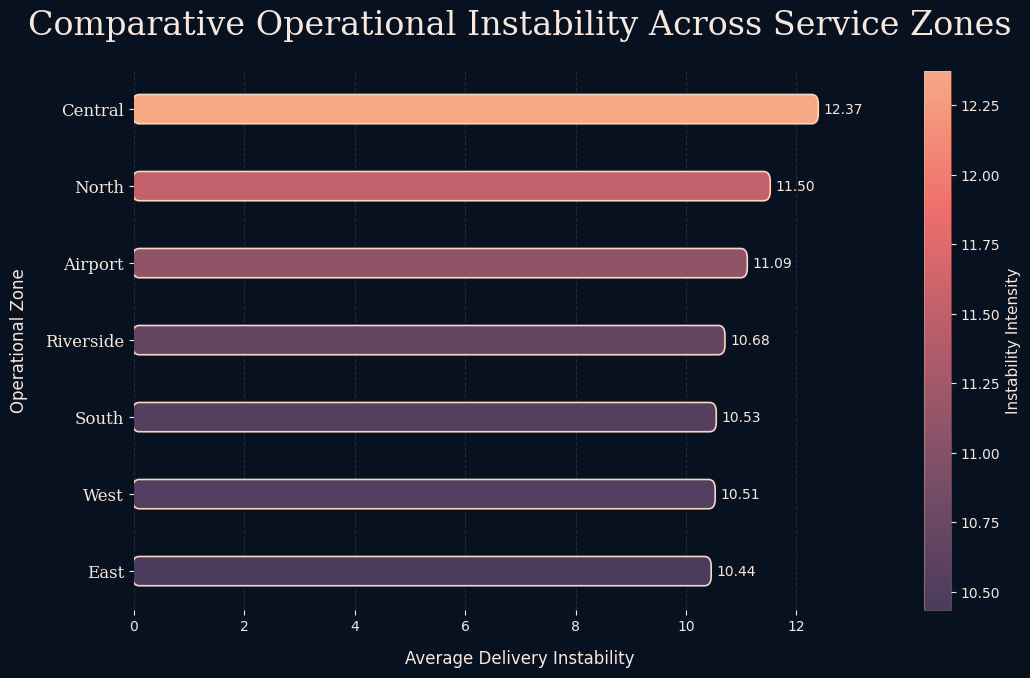

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import FancyBboxPatch

# -----------------------------
# SORT DATA
# -----------------------------

bar_df = zone_analysis.sort_values(
    "avg_instability",
    ascending=True
)

zones = bar_df["zone"]
instability = bar_df["avg_instability"]

# -----------------------------
# SAME PALETTE
# -----------------------------

cmap = LinearSegmentedColormap.from_list(
    "reference_peach_palette",
    [
        "#4B3B5C",
        "#7B4F67",
        "#B65C6B",
        "#EF6F6C",
        "#F6A985"
    ]
)

norm = Normalize(
    vmin=instability.min(),
    vmax=instability.max()
)

bar_colors = cmap(norm(instability))

# -----------------------------
# FIGURE
# -----------------------------

fig, ax = plt.subplots(
    figsize=(12, 7),
    facecolor="#07111f"
)

ax.set_facecolor("#07111f")

# -----------------------------
# THIN ROUNDED BARS
# -----------------------------

y_positions = np.arange(len(zones))

bar_height = 0.34

for y, value, color in zip(y_positions, instability, bar_colors):

    rounded_bar = FancyBboxPatch(
        (0, y - bar_height / 2),
        value,
        bar_height,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        linewidth=1.2,
        edgecolor="#f8d7c2",
        facecolor=color
    )

    ax.add_patch(rounded_bar)

    # VALUE LABELS
    ax.text(
        value + 0.12,
        y,
        f"{value:.2f}",
        va="center",
        fontsize=10,
        color="#f7e7dc"
    )

# -----------------------------
# AXIS SETTINGS
# -----------------------------

ax.set_xlim(0, instability.max() + 1.6)

ax.set_ylim(-0.5, len(zones) - 0.5)

ax.set_yticks(y_positions)
ax.set_yticklabels(
    zones,
    fontsize=12,
    color="#f7e7dc",
    fontfamily="serif"
)

# -----------------------------
# GRID
# -----------------------------

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.12,
    color="#f8d7c2"
)

ax.set_axisbelow(True)

# -----------------------------
# LABELS
# -----------------------------

ax.set_xlabel(
    "Average Delivery Instability",
    fontsize=12,
    color="#f7e7dc",
    labelpad=12
)

ax.set_ylabel(
    "Operational Zone",
    fontsize=12,
    color="#f7e7dc",
    labelpad=12
)

# -----------------------------
# TITLE
# -----------------------------

plt.title(
    "Comparative Operational Instability Across Service Zones",
    fontsize=24,
    color="#f7e7dc",
    pad=26,
    fontfamily="serif"
)

# -----------------------------
# TICKS
# -----------------------------

ax.tick_params(colors="#f7e7dc")

# -----------------------------
# REMOVE SPINES
# -----------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

# -----------------------------
# COLORBAR
# -----------------------------

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    "Instability Intensity",
    color="#f7e7dc",
    fontsize=11
)

cbar.ax.tick_params(colors="#f7e7dc")

cbar.outline.set_edgecolor("#f8d7c2")
cbar.outline.set_alpha(0.3)

# -----------------------------
# SHOW
# -----------------------------

plt.show()

## 3.1 - Zone Stress Score Construction

# This section creates a combined Zone Stress Score to evaluate operational pressure more holistically. Instead of relying only on instability, the score includes failure rate, delivery volume, and customer rating deterioration.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# COPY ZONE DATA

zone_score_df = zone_analysis.copy()

# CREATE LOW RATING PRESSURE

zone_score_df["rating_pressure"] = (
    zone_score_df["avg_customer_rating"].max() - zone_score_df["avg_customer_rating"]
)

# SCALE VARIABLES

scaler = MinMaxScaler()

scaled_zone = scaler.fit_transform(zone_score_df[[
    "avg_instability",
    "failure_rate",
    "delivery_volume",
    "rating_pressure"
]])

scaled_zone_df = pd.DataFrame(
    scaled_zone,
    columns=[
        "instability_scaled",
        "failure_scaled",
        "volume_scaled",
        "rating_pressure_scaled"
    ],
    index=zone_score_df.index
)

# FINAL ZONE STRESS SCORE

zone_score_df["zone_stress_score"] = (
    (0.40 * scaled_zone_df["instability_scaled"]) +
    (0.30 * scaled_zone_df["failure_scaled"]) +
    (0.15 * scaled_zone_df["volume_scaled"]) +
    (0.15 * scaled_zone_df["rating_pressure_scaled"])
) * 100

zone_score_df = zone_score_df.sort_values(
    "zone_stress_score",
    ascending=False
)

zone_score_df[[
    "zone",
    "avg_instability",
    "failure_rate",
    "avg_customer_rating",
    "delivery_volume",
    "zone_stress_score"
]]

,zone,avg_instability,failure_rate,avg_customer_rating,delivery_volume,zone_stress_score
1,Central,12.374072,13.513514,3.766207,185,95.714286
3,North,11.504417,13.089005,3.830979,191,72.244931
5,South,10.527392,10.112360,3.847187,178,28.038000
4,Riverside,10.684773,10.497238,3.957357,181,26.056003
0,Airport,11.088989,8.588957,3.871500,163,23.079815
6,West,10.507898,8.629442,3.923077,197,19.432461
2,East,10.435402,9.032258,3.857778,155,10.514776


### Interpretation

The Zone Stress Score gives a broader view of operational pressure by combining instability, failures, customer dissatisfaction, and workload. This helps identify zones that are not only unstable, but also operationally costly and customer-impacting.

## Zone Stress Score Visualisation

This visual compares the overall operational stress of each service zone using the combined Zone Stress Score. The score includes instability, failure rate, customer rating pressure, and delivery volume, making it more complete than a single-metric ranking.

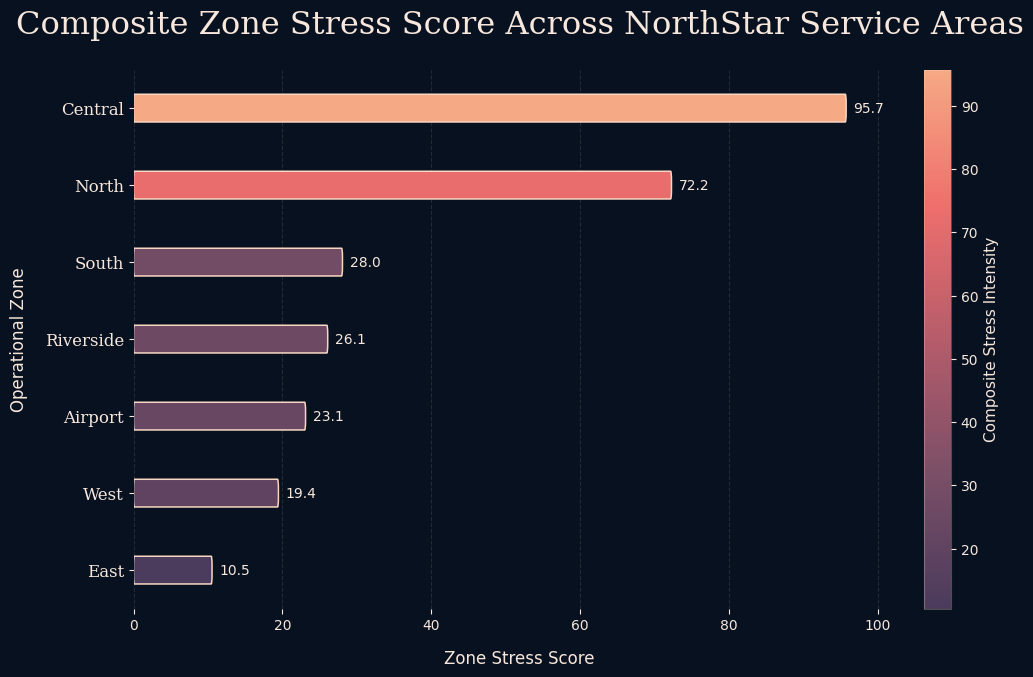

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import FancyBboxPatch

# SORT DATA
stress_df = zone_score_df.sort_values("zone_stress_score", ascending=True)

zones = stress_df["zone"]
stress_score = stress_df["zone_stress_score"]

# COLOUR PALETTE
cmap = LinearSegmentedColormap.from_list(
    "stress_palette",
    ["#4B3B5C", "#7B4F67", "#B65C6B", "#EF6F6C", "#F6A985"]
)

norm = Normalize(vmin=stress_score.min(), vmax=stress_score.max())
bar_colors = cmap(norm(stress_score))

# FIGURE
fig, ax = plt.subplots(figsize=(12, 7), facecolor="#07111f")
ax.set_facecolor("#07111f")

# ROUNDED THIN BARS
y_positions = np.arange(len(zones))
bar_height = 0.32

for y, value, color in zip(y_positions, stress_score, bar_colors):
    rounded_bar = FancyBboxPatch(
        (0, y - bar_height / 2),
        value,
        bar_height,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        linewidth=1.1,
        edgecolor="#f8d7c2",
        facecolor=color
    )

    ax.add_patch(rounded_bar)

    ax.text(
        value + 1,
        y,
        f"{value:.1f}",
        va="center",
        fontsize=10,
        color="#f7e7dc"
    )

# AXIS SETTINGS
ax.set_xlim(0, stress_score.max() + 8)
ax.set_ylim(-0.5, len(zones) - 0.5)

ax.set_yticks(y_positions)
ax.set_yticklabels(
    zones,
    fontsize=12,
    color="#f7e7dc",
    fontfamily="serif"
)

ax.xaxis.grid(True, linestyle="--", alpha=0.12, color="#f8d7c2")
ax.set_axisbelow(True)

# LABELS
ax.set_xlabel(
    "Zone Stress Score",
    fontsize=12,
    color="#f7e7dc",
    labelpad=12
)

ax.set_ylabel(
    "Operational Zone",
    fontsize=12,
    color="#f7e7dc",
    labelpad=12
)

# TITLE
plt.title(
    "Composite Zone Stress Score Across NorthStar Service Areas",
    fontsize=23,
    color="#f7e7dc",
    pad=26,
    fontfamily="serif"
)

# TICKS AND SPINES
ax.tick_params(colors="#f7e7dc")

for spine in ax.spines.values():
    spine.set_visible(False)

# COLOURBAR
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, pad=0.02)

cbar.set_label(
    "Composite Stress Intensity",
    color="#f7e7dc",
    fontsize=11
)

cbar.ax.tick_params(colors="#f7e7dc")
cbar.outline.set_edgecolor("#f8d7c2")
cbar.outline.set_alpha(0.3)

plt.show()

### Interpretation

The composite score highlights zones where multiple operational warning signals overlap. A high score indicates that the zone is not only unstable, but also affected by failure pressure, workload demand, and weaker customer satisfaction.

# Section 4 — Route Override and Delivery Instability Analysis

### Objective

The purpose of this section is to investigate whether repeated manual route overrides contribute to higher operational instability and weaker delivery performance.

This analysis examines whether override frequency behaves as a meaningful operational pressure signal rather than normal routing variation.

### Analytical Approach

Deliveries were grouped according to override intensity levels ranging from no overrides to high override pressure.

Operational instability, failure rate, customer satisfaction, and average delivery duration were then compared across these groups to evaluate whether override behaviour is associated with deteriorating operational performance.

In [ ]:
# CREATE OVERRIDE CATEGORIES
main_df["override_category"] = pd.cut(
    main_df["manual_route_override_count"],
    bins=[-1, 0, 1, 3, main_df["manual_route_override_count"].max()],
    labels=[
        "No Override",
        "Low Override",
        "Moderate Override",
        "High Override"
    ]
)

# GROUPED OVERRIDE ANALYSIS
override_analysis = main_df.groupby(
    "override_category",
    observed=True
).agg({
    "delivery_instability_index": "mean",
    "customer_rating_post_delivery": "mean",
    "is_failed_delivery": "mean",
    "delivery_duration_hours": "mean",
    "order_id": "count"
}).reset_index()

# FAILURE RATE %
override_analysis["failure_rate"] = (
    override_analysis["is_failed_delivery"] * 100
)

# RENAME COLUMNS
override_analysis = override_analysis.rename(columns={
    "delivery_instability_index": "avg_instability",
    "customer_rating_post_delivery": "avg_customer_rating",
    "delivery_duration_hours": "avg_delivery_duration",
    "order_id": "delivery_count"
})

override_analysis[[
    "override_category",
    "delivery_count",
    "avg_instability",
    "failure_rate",
    "avg_customer_rating",
    "avg_delivery_duration"
]]

,override_category,delivery_count,avg_instability,failure_rate,avg_customer_rating,avg_delivery_duration
0,No Override,699,7.810803,6.580830,3.900816,9.247345
1,Low Override,310,12.667233,16.451613,3.884463,10.176912
2,Moderate Override,210,16.334887,15.238095,3.782136,9.641492
3,High Override,31,31.370824,9.677419,3.760323,10.717441


There is a nonlinear pattern visible here

| Override Level    | Avg Instability |
| ----------------- | --------------- |
| No Override       | 7.81            |
| Low Override      | 12.67           |
| Moderate Override | 16.33           |
| High Override     | 31.37           |

This jump in particular is very out of bounds:

Moderate → High

16 → 31

This is a threshold amplification behavior.

And when you look at this

| Override | Failure Rate |
| -------- | ------------ |
| Moderate | 15.2%        |
| High     | 9.7%         |

This may look contradictory but this implies that instability is not equal to immediate failure.

High override deliveries may remain technically completed BUT require huge operational intervention

Meaning:
the system is compensating aggressively before collapse.

We should also note that customer ratings steadily decline, which means even if deliveries survive, customers still experience:
-friction
-inconsistency
-degraded service quality

## Nonlinear Instability Escalation Across Override Pressure Levels

The following visualization illustrates how operational instability escalates across increasing levels of manual route override pressure.

The sharp rise in instability under high override conditions suggests that override behaviour may function as an operational stress amplifier rather than a minor routing adjustment mechanism.

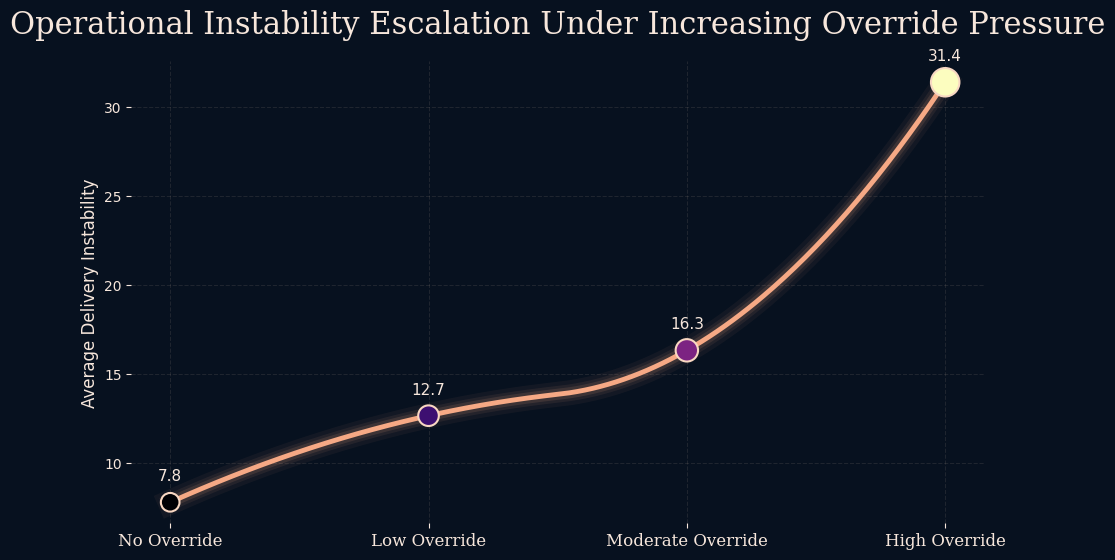

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# DATA
categories = override_analysis["override_category"]
instability = override_analysis["avg_instability"]

x = np.arange(len(categories))

# SMOOTH CURVE
x_smooth = np.linspace(x.min(), x.max(), 300)

spline = make_interp_spline(x, instability, k=2)

y_smooth = spline(x_smooth)

# FIGURE
fig, ax = plt.subplots(
    figsize=(11, 6),
    facecolor="#07111f"
)

ax.set_facecolor("#07111f")

# GLOW LAYERS
for linewidth, alpha in zip(
    [18, 12, 8],
    [0.05, 0.08, 0.12]
):
    ax.plot(
        x_smooth,
        y_smooth,
        color="#F6A985",
        linewidth=linewidth,
        alpha=alpha
    )

# MAIN CURVE
ax.plot(
    x_smooth,
    y_smooth,
    color="#F6A985",
    linewidth=3.5
)

# SCATTER POINTS
scatter = ax.scatter(
    x,
    instability,
    s=[180, 220, 260, 420],
    c=instability,
    cmap="magma",
    edgecolor="#f8d7c2",
    linewidth=1.5,
    zorder=5
)

# VALUE LABELS
for i, value in enumerate(instability):
    ax.text(
        x[i],
        value + 1.2,
        f"{value:.1f}",
        ha="center",
        color="#f7e7dc",
        fontsize=11
    )

# GRID
ax.grid(
    color="#f8d7c2",
    alpha=0.10,
    linestyle="--"
)

# LABELS
ax.set_xticks(x)

ax.set_xticklabels(
    categories,
    fontsize=12,
    color="#f7e7dc",
    fontfamily="serif"
)

ax.set_ylabel(
    "Average Delivery Instability",
    fontsize=12,
    color="#f7e7dc"
)

# TITLE
plt.title(
    "Operational Instability Escalation Under Increasing Override Pressure",
    fontsize=22,
    color="#f7e7dc",
    pad=20,
    fontfamily="serif"
)

# REMOVE SPINES
for spine in ax.spines.values():
    spine.set_visible(False)

# TICKS
ax.tick_params(colors="#f7e7dc")

plt.show()

### Interpretation

Operational instability increases sharply as override intensity rises, particularly under high override conditions where instability nearly doubles compared to moderate override levels.

This suggests that repeated manual route intervention may behave as a nonlinear operational stress amplifier rather than a minor routing adjustment process.

# Section 5 — Driver Performance and Operational Risk Analysis

### Objective

This section investigates whether driver-related operational factors such as training score, driving experience, and route override behaviour are associated with elevated operational instability and delivery disruption.

### Analytical Approach

Driver-level operational metrics were aggregated to identify patterns between behavioural characteristics and delivery performance outcomes.

The analysis examines whether instability clusters emerge under combinations of weaker training, repeated overrides, lower ratings, and incident involvement.

In [ ]:
# DRIVER-LEVEL AGGREGATION

driver_analysis = main_df.groupby("driver_id").agg({
    "delivery_instability_index": "mean",
    "manual_route_override_count": "mean",
    "incident_count": "sum",
    "driver_rating": "mean",
    "training_score": "mean",
    "years_experience": "mean",
    "is_failed_delivery": "mean",
    "order_id": "count"
}).reset_index()

# FAILURE RATE %
driver_analysis["failure_rate"] = (
    driver_analysis["is_failed_delivery"] * 100
)

# RENAME COLUMNS
driver_analysis = driver_analysis.rename(columns={
    "delivery_instability_index": "avg_instability",
    "manual_route_override_count": "avg_override_count",
    "order_id": "delivery_count"
})

driver_analysis.head()

,driver_id,avg_instability,avg_override_count,incident_count,driver_rating,training_score,years_experience,is_failed_delivery,delivery_count,failure_rate
0,D001,16.292348,0.666667,2.0,3.54,67.8,8.0,0.166667,6,16.666667
1,D002,12.171789,1.000000,4.0,3.94,42.4,4.0,0.142857,7,14.285714
2,D003,11.098807,1.750000,2.0,5.00,96.5,11.0,0.000000,4,0.000000
3,D004,16.149531,0.777778,5.0,4.75,88.9,13.0,0.333333,9,33.333333
4,D005,17.327237,1.200000,2.0,4.14,69.7,3.0,0.400000,5,40.000000


## Driver Instability Interaction Field
The following visualization explores the relationship between driver training quality, operational instability, and delivery failure pressure.

Rather than evaluating individual drivers separately, the graph identifies behavioural regions where operational instability appears to accumulate more intensely.

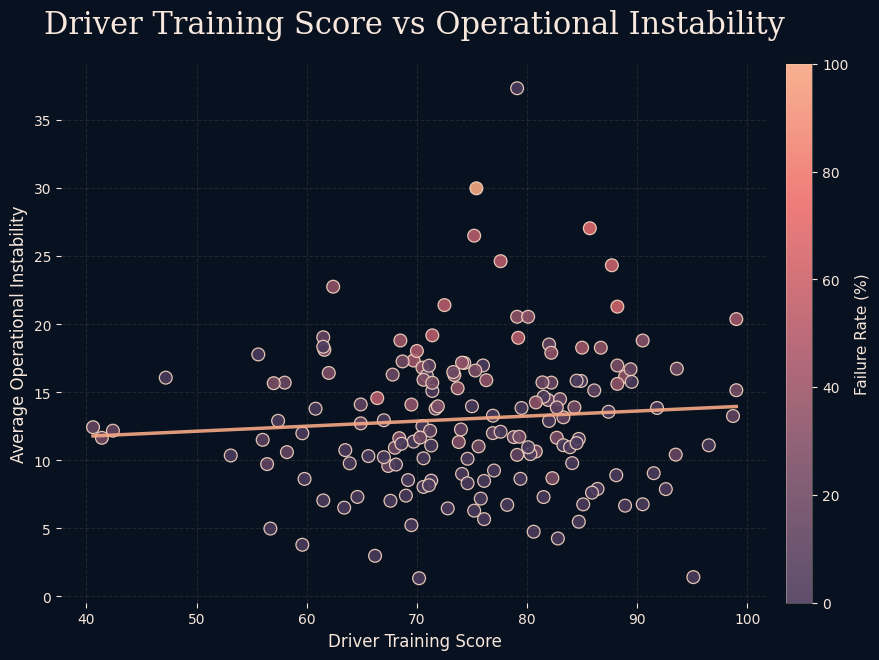

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize

# DATA
plot_df = driver_analysis.dropna(subset=[
    "training_score",
    "avg_instability",
    "failure_rate"
]).copy()

x = plot_df["training_score"].values
y = plot_df["avg_instability"].values
failure = plot_df["failure_rate"].values

# PALETTE
cmap = LinearSegmentedColormap.from_list(
    "driver_palette",
    ["#4B3B5C", "#7B4F67", "#B65C6B", "#EF6F6C", "#F6A985"]
)

norm = Normalize(vmin=failure.min(), vmax=failure.max())

# TREND LINE
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)
x_line = np.linspace(x.min(), x.max(), 200)

# FIGURE
fig, ax = plt.subplots(figsize=(11, 7), facecolor="#07111f")
ax.set_facecolor("#07111f")

scatter = ax.scatter(
    x, y,
    c=failure,
    cmap=cmap,
    s=85,
    edgecolor="#f8d7c2",
    linewidth=0.9,
    alpha=0.9
)

ax.plot(
    x_line,
    trend(x_line),
    color="#F6A985",
    linewidth=2.5,
    alpha=0.9
)

ax.grid(color="#f8d7c2", alpha=0.10, linestyle="--")

ax.set_xlabel("Driver Training Score", color="#f7e7dc", fontsize=12)
ax.set_ylabel("Average Operational Instability", color="#f7e7dc", fontsize=12)

plt.title(
    "Driver Training Score vs Operational Instability",
    fontsize=22,
    color="#f7e7dc",
    pad=22,
    fontfamily="serif"
)

ax.tick_params(colors="#f7e7dc")

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Failure Rate (%)", color="#f7e7dc", fontsize=11)
cbar.ax.tick_params(colors="#f7e7dc")
cbar.outline.set_edgecolor("#f8d7c2")
cbar.outline.set_alpha(0.3)

plt.show()

### Interpretation

The scatter plot shows that operational instability does not decrease consistently as training score increases. Although several highly trained drivers operate within stable conditions, elevated instability and failure pressure still appear across multiple training levels, suggesting that driver performance is influenced by broader operational conditions rather than training quality alone.

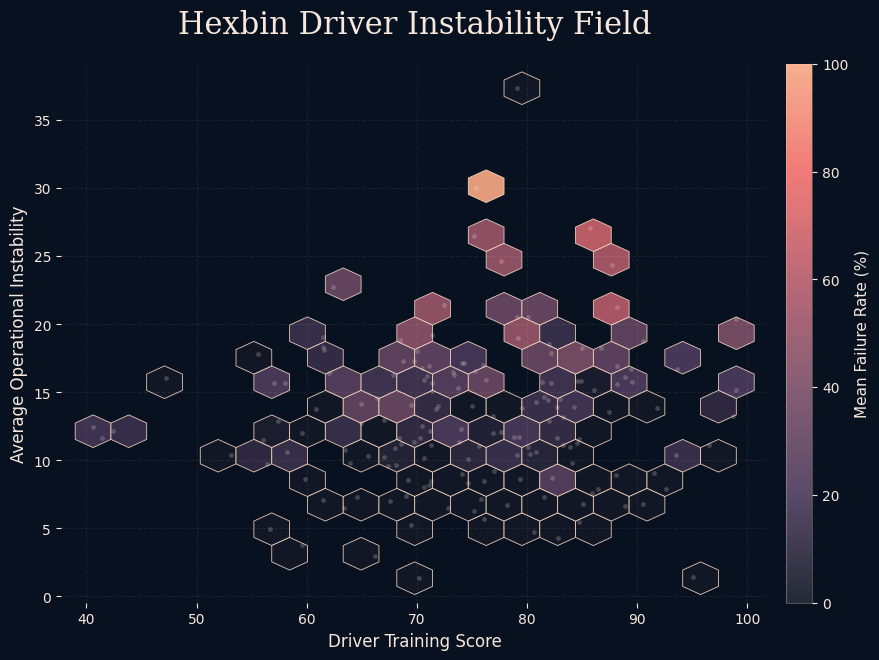

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# DATA
plot_df = driver_analysis.dropna(subset=[
    "training_score",
    "avg_instability",
    "failure_rate"
]).copy()

x = plot_df["training_score"].values
y = plot_df["avg_instability"].values
failure = plot_df["failure_rate"].values

# PALETTE
cmap = LinearSegmentedColormap.from_list(
    "hex_driver_palette",
    ["#121826", "#4B3B5C", "#7B4F67", "#B65C6B", "#EF6F6C", "#F6A985"]
)

# FIGURE
fig, ax = plt.subplots(figsize=(11, 7), facecolor="#07111f")
ax.set_facecolor("#07111f")

# HEXBIN FIELD
hb = ax.hexbin(
    x,
    y,
    C=failure,
    gridsize=18,
    reduce_C_function=np.mean,
    cmap=cmap,
    mincnt=1,
    linewidths=0.6,
    edgecolors="#f8d7c2",
    alpha=0.92
)

# SUBTLE POINT OVERLAY
ax.scatter(
    x,
    y,
    s=12,
    color="#f7e7dc",
    alpha=0.22,
    linewidth=0
)

# GRID
ax.grid(
    color="#f8d7c2",
    alpha=0.08,
    linestyle="--"
)

# LABELS
ax.set_xlabel(
    "Driver Training Score",
    color="#f7e7dc",
    fontsize=12
)

ax.set_ylabel(
    "Average Operational Instability",
    color="#f7e7dc",
    fontsize=12
)

# TITLE
plt.title(
    "Hexbin Driver Instability Field",
    fontsize=22,
    color="#f7e7dc",
    pad=22,
    fontfamily="serif"
)

# TICKS
ax.tick_params(colors="#f7e7dc")

# REMOVE SPINES
for spine in ax.spines.values():
    spine.set_visible(False)

# COLORBAR
cbar = plt.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label(
    "Mean Failure Rate (%)",
    color="#f7e7dc",
    fontsize=11
)

cbar.ax.tick_params(colors="#f7e7dc")
cbar.outline.set_edgecolor("#f8d7c2")
cbar.outline.set_alpha(0.3)

plt.show()

### Interpretation

The hexbin field reveals that operational instability tends to concentrate within specific behavioural regions rather than appearing randomly across drivers. Higher instability and failure pressure become more noticeable under moderate-to-high override conditions, suggesting that repeated manual intervention may amplify operational disruption even among drivers with acceptable training scores.

### Why a Hexbin Visualization Was Introduced

While the scatter plot provides visibility into individual driver behaviour, overlapping observations make it difficult to identify broader instability concentration patterns. The hexbin field was therefore introduced to reduce visual fragmentation and reveal regions where operational instability and failure pressure accumulate more densely across the driver landscape.

# Section 6 — Vehicle Reliability and Operational Degradation Analysis

### Objective

This section investigates whether deteriorating vehicle condition contributes to elevated operational instability within NorthStar’s logistics network.

The analysis evaluates how battery health, accumulated mileage, override behaviour, and operational failures interact across the vehicle fleet.

### Analytical Approach

Vehicle-level operational metrics were aggregated to examine whether degradation indicators such as lower battery health and higher odometer accumulation are associated with increased delivery instability and operational disruption.

The goal is to determine whether vehicle condition behaves as an underlying operational stress amplifier.

In [ ]:
# VEHICLE-LEVEL AGGREGATION

vehicle_analysis = main_df.groupby("vehicle_id").agg({
    "delivery_instability_index": "mean",
    "manual_route_override_count": "mean",
    "incident_count": "sum",
    "battery_health_pct": "mean",
    "odometer_km": "mean",
    "is_failed_delivery": "mean",
    "order_id": "count"
}).reset_index()

# FAILURE RATE %
vehicle_analysis["failure_rate"] = (
    vehicle_analysis["is_failed_delivery"] * 100
)

# RENAME COLUMNS
vehicle_analysis = vehicle_analysis.rename(columns={
    "delivery_instability_index": "avg_instability",
    "manual_route_override_count": "avg_override_count",
    "order_id": "delivery_count"
})

vehicle_analysis.head()

,vehicle_id,avg_instability,avg_override_count,incident_count,battery_health_pct,odometer_km,is_failed_delivery,delivery_count,failure_rate
0,V001,10.273420,0.800000,4.0,71.8,56928.0,0.000000,10,0.000000
1,V002,20.037776,1.375000,1.0,67.9,159368.0,0.500000,8,50.000000
2,V003,12.058893,0.000000,1.0,91.7,219359.0,0.000000,1,0.000000
3,V004,13.758672,1.300000,1.0,NaN,36310.0,0.100000,10,10.000000
4,V005,14.571579,1.307692,5.0,58.6,146638.0,0.153846,13,15.384615


### HANDLE MISSING BATTERY HEALTH

In [ ]:
# HANDLE MISSING BATTERY HEALTH

vehicle_analysis["battery_health_pct"] = (
    vehicle_analysis["battery_health_pct"]
    .fillna(vehicle_analysis["battery_health_pct"].median())
)

## Vehicle Degradation and Operational Instability Field

The following visualization examines how vehicle degradation characteristics interact with operational instability across NorthStar’s fleet.

Battery condition, instability, incident involvement, and failure pressure are represented simultaneously to identify operationally vulnerable vehicle regions.

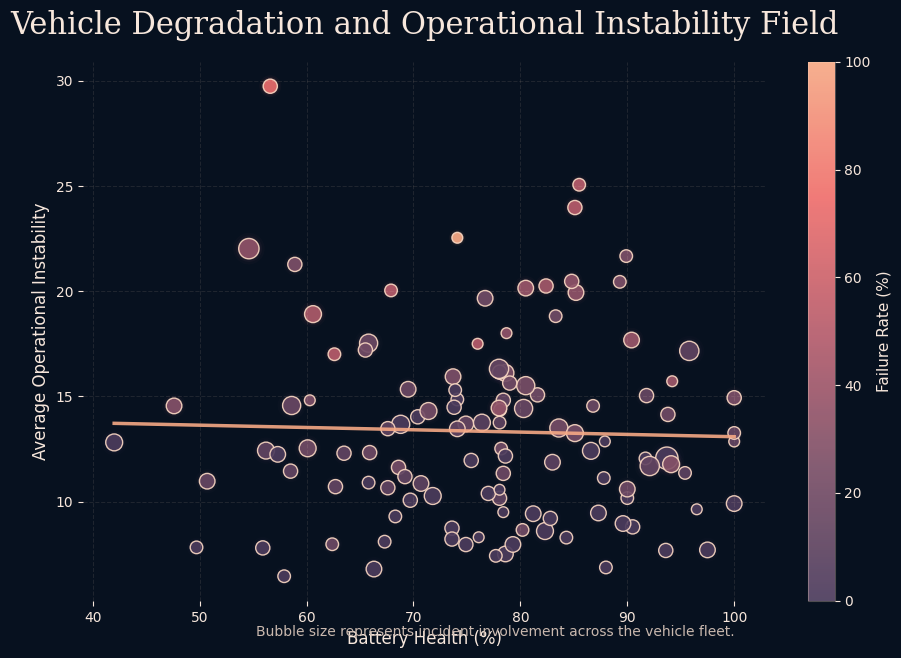

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize

# DATA
plot_df = vehicle_analysis.dropna(subset=[
    "battery_health_pct",
    "avg_instability",
    "failure_rate",
    "incident_count"
]).copy()

x = plot_df["battery_health_pct"].values

y = plot_df["avg_instability"].values

failure = plot_df["failure_rate"].values

incidents = plot_df["incident_count"].values

# POINT SIZE
point_size = 60 + (incidents * 22)

# COLOUR PALETTE
cmap = LinearSegmentedColormap.from_list(
    "vehicle_palette",
    [
        "#4B3B5C",
        "#7B4F67",
        "#B65C6B",
        "#EF6F6C",
        "#F6A985"
    ]
)

norm = Normalize(
    vmin=failure.min(),
    vmax=failure.max()
)

# TREND LINE
coef = np.polyfit(x, y, 1)

trend = np.poly1d(coef)

x_line = np.linspace(x.min(), x.max(), 200)

# FIGURE
fig, ax = plt.subplots(
    figsize=(11, 7),
    facecolor="#07111f"
)

ax.set_facecolor("#07111f")

# GLOW LAYERS
for scale, alpha in zip(
    [2.4, 1.7, 1.3],
    [0.04, 0.07, 0.10]
):

    ax.scatter(
        x,
        y,
        s=point_size * scale,
        c=failure,
        cmap=cmap,
        alpha=alpha,
        edgecolors="none"
    )

# MAIN POINTS
scatter = ax.scatter(
    x,
    y,
    s=point_size,
    c=failure,
    cmap=cmap,
    edgecolor="#f8d7c2",
    linewidth=1,
    alpha=0.92
)

# TREND LINE
ax.plot(
    x_line,
    trend(x_line),
    color="#F6A985",
    linewidth=2.5,
    alpha=0.9
)

# LABELS
ax.set_xlabel(
    "Battery Health (%)",
    fontsize=12,
    color="#f7e7dc"
)

ax.set_ylabel(
    "Average Operational Instability",
    fontsize=12,
    color="#f7e7dc"
)

# GRID
ax.grid(
    color="#f8d7c2",
    alpha=0.10,
    linestyle="--"
)

# TITLE
plt.title(
    "Vehicle Degradation and Operational Instability Field",
    fontsize=22,
    color="#f7e7dc",
    pad=20,
    fontfamily="serif"
)

# TICKS
ax.tick_params(colors="#f7e7dc")

# REMOVE SPINES
for spine in ax.spines.values():
    spine.set_visible(False)

# COLORBAR
cbar = plt.colorbar(scatter)

cbar.set_label(
    "Failure Rate (%)",
    color="#f7e7dc",
    fontsize=11
)

cbar.ax.tick_params(colors="#f7e7dc")

cbar.outline.set_edgecolor("#f8d7c2")
cbar.outline.set_alpha(0.3)

# FOOTNOTE
fig.text(
    0.5,
    0.06,
    "Bubble size represents incident involvement across the vehicle fleet.",
    ha="center",
    color="#c9b8ae",
    fontsize=10
)

plt.show()

### Interpretation

The degradation field suggests that operational instability tends to increase as battery health weakens, although the relationship is not perfectly linear. Vehicles with stronger failure pressure and higher incident involvement appear more frequently within elevated instability regions, indicating that degradation-related operational risk emerges through multiple interacting conditions rather than mileage or battery condition alone.

## 3D Vehicle Degradation Risk Landscape

The following visualization models operational instability as a degradation landscape across the vehicle fleet.

The surface explores how battery deterioration and accumulated mileage interact with delivery instability and operational failure pressure.

### Why a 3D Operational Landscape Was Included

The multidimensional scatter plot provides the most accurate representation of the underlying vehicle relationships. However, operational degradation patterns can still be difficult to interpret intuitively when multiple variables interact simultaneously.

The 3D landscape was therefore introduced as a **supplementary systems-level visualization** to provide a more spatial understanding of how instability regions emerge across combinations of vehicle degradation conditions.

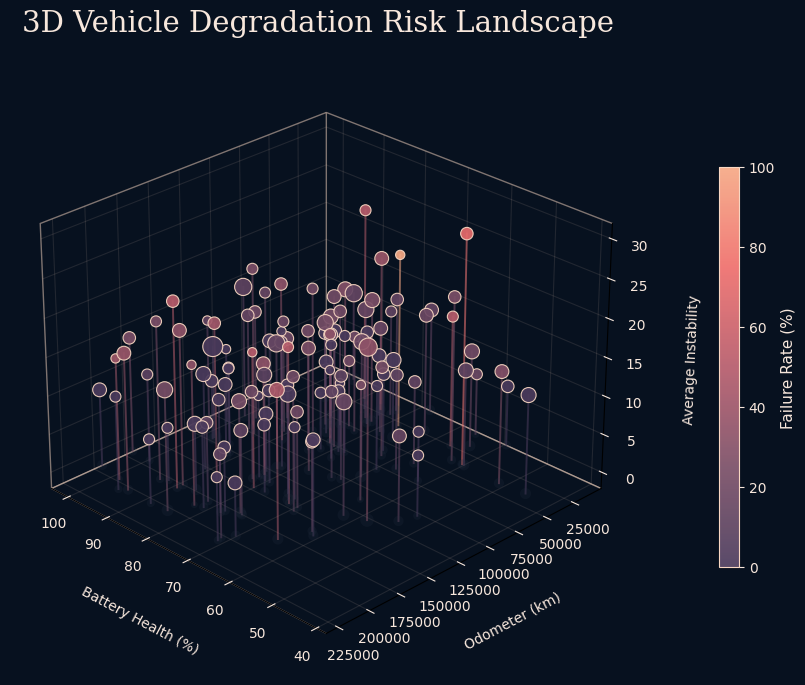

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize

# DATA
plot_df = vehicle_analysis.dropna(subset=[
    "battery_health_pct",
    "odometer_km",
    "avg_instability",
    "failure_rate",
    "incident_count"
]).copy()

x = plot_df["battery_health_pct"].values
y = plot_df["odometer_km"].values
z = plot_df["avg_instability"].values
failure = plot_df["failure_rate"].values
incidents = plot_df["incident_count"].values

# COLOUR PALETTE
cmap = LinearSegmentedColormap.from_list(
    "vehicle_3d_palette",
    ["#4B3B5C", "#7B4F67", "#B65C6B", "#EF6F6C", "#F6A985"]
)

norm = Normalize(vmin=failure.min(), vmax=failure.max())

# POINT SIZE
point_size = 45 + (incidents * 18)

# FIGURE
fig = plt.figure(figsize=(12, 8), facecolor="#07111f")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("#07111f")

# BASE SHADOW POINTS
ax.scatter(
    x,
    y,
    np.zeros_like(z),
    c="#2b3446",
    s=point_size * 0.55,
    alpha=0.18,
    edgecolor="none"
)

# VERTICAL RISK STEMS
for xi, yi, zi, fail in zip(x, y, z, failure):
    ax.plot(
        [xi, xi],
        [yi, yi],
        [0, zi],
        color=cmap(norm(fail)),
        linewidth=1.4,
        alpha=0.55
    )

# REAL VEHICLE POINTS
scatter = ax.scatter(
    x,
    y,
    z,
    c=failure,
    cmap=cmap,
    s=point_size,
    edgecolor="#f8d7c2",
    linewidth=0.8,
    alpha=0.92
)

# LABELS
ax.set_xlabel("Battery Health (%)", color="#f7e7dc", labelpad=14)
ax.set_ylabel("Odometer (km)", color="#f7e7dc", labelpad=14)
ax.set_zlabel("Average Instability", color="#f7e7dc", labelpad=14)

# TITLE
ax.set_title(
    "3D Vehicle Degradation Risk Landscape",
    fontsize=21,
    color="#f7e7dc",
    pad=20,
    fontfamily="serif"
)

# DARK STYLE
ax.tick_params(colors="#f7e7dc")

ax.xaxis.pane.set_facecolor("#07111f")
ax.yaxis.pane.set_facecolor("#07111f")
ax.zaxis.pane.set_facecolor("#07111f")

ax.xaxis.pane.set_edgecolor("#f8d7c2")
ax.yaxis.pane.set_edgecolor("#f8d7c2")
ax.zaxis.pane.set_edgecolor("#f8d7c2")

ax.xaxis._axinfo["grid"]["color"] = (0.97, 0.84, 0.76, 0.11)
ax.yaxis._axinfo["grid"]["color"] = (0.97, 0.84, 0.76, 0.11)
ax.zaxis._axinfo["grid"]["color"] = (0.97, 0.84, 0.76, 0.11)

# VIEW ANGLE
ax.view_init(elev=27, azim=135)

# COLORBAR
cbar = fig.colorbar(scatter, ax=ax, shrink=0.65, pad=0.10)
cbar.set_label("Failure Rate (%)", color="#f7e7dc", fontsize=11)
cbar.ax.tick_params(colors="#f7e7dc")
cbar.outline.set_edgecolor("#f8d7c2")

plt.show()

### Interpretation

The 3D vehicle risk landscape shows that operational instability is not explained by mileage or battery health alone. Vehicles with stronger failure pressure appear as higher and warmer points, suggesting that degradation-related risk is shaped by multiple interacting vehicle conditions.

# Section 7 — Platform Event Stream and Latency Analysis

### Objective

This section investigates whether NorthStar’s mobile platform shows signs of technical friction through API latency and event success behaviour.

The aim is to understand whether app-event performance may contribute to service inconsistency, failed interactions, or weaker customer experience.
### Analytical Approach

App events were analysed by event type to compare average API latency, success rate, and event volume.

This allows platform behaviour to be evaluated as part of the wider operational system rather than as a separate technical issue.

In [ ]:
# APP EVENT TYPE ANALYSIS

app_event_analysis = app_events.groupby("event_type").agg({
    "api_latency_ms": "mean",
    "success_flag": "mean",
    "event_id": "count"
}).reset_index()

# SUCCESS RATE %
app_event_analysis["success_rate"] = app_event_analysis["success_flag"] * 100

# RENAME COLUMNS
app_event_analysis = app_event_analysis.rename(columns={
    "api_latency_ms": "avg_api_latency_ms",
    "event_id": "event_count"
})

app_event_analysis = app_event_analysis.sort_values(
    "avg_api_latency_ms",
    ascending=False
)

app_event_analysis[[
    "event_type",
    "event_count",
    "avg_api_latency_ms",
    "success_rate"
]]

,event_type,event_count,avg_api_latency_ms,success_rate
3,delivery_instruction_update,75,496.293333,100.000000
2,chat_opened,88,478.329545,100.000000
1,chat_escalated,38,478.131579,50.000000
5,payment_retry,69,472.681159,72.463768
7,track_order,138,460.710145,100.000000
6,search_route,99,456.505051,100.000000
4,eta_refresh,105,452.152381,100.000000
0,cancel_attempt,28,417.142857,100.000000


## API Latency Deviation Across Event Types

The following visualization compares average API latency across major platform interaction events.

Events positioned further from the system-wide average indicate regions where technical friction and operational slowdown become more concentrated.

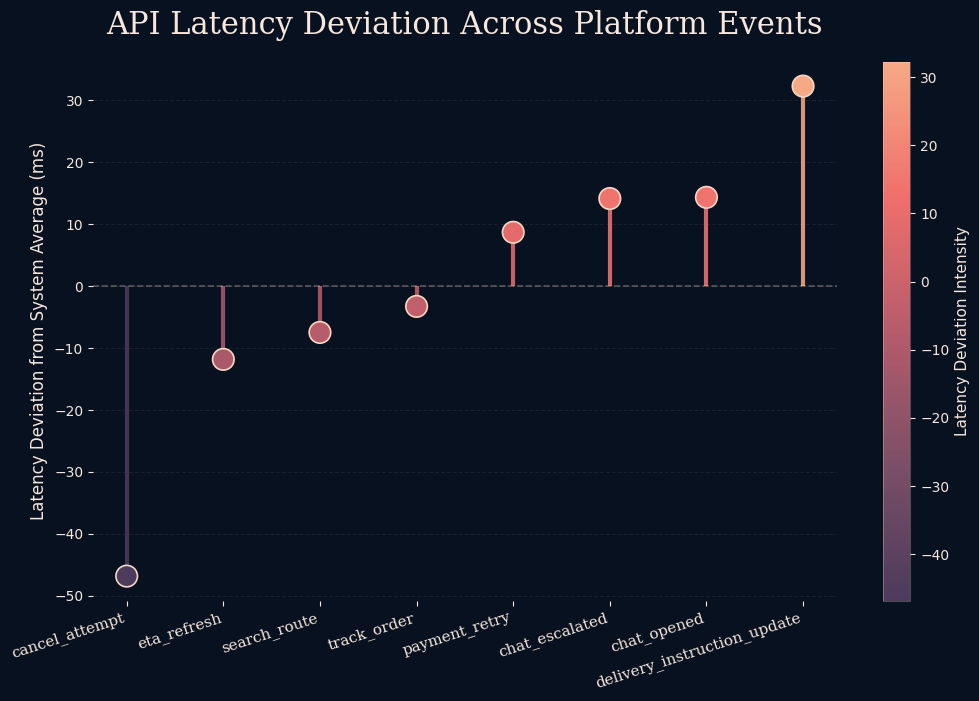

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize

# DATA
plot_df = app_event_analysis.copy()

# SYSTEM AVERAGE
system_avg = plot_df["avg_api_latency_ms"].mean()

# DEVIATION
plot_df["latency_deviation"] = (
    plot_df["avg_api_latency_ms"] - system_avg
)

# SORT
plot_df = plot_df.sort_values(
    "latency_deviation"
)

# VARIABLES
events = plot_df["event_type"]
deviation = plot_df["latency_deviation"]

x = np.arange(len(events))

# COLOUR PALETTE
cmap = LinearSegmentedColormap.from_list(
    "latency_palette",
    [
        "#4B3B5C",
        "#7B4F67",
        "#B65C6B",
        "#EF6F6C",
        "#F6A985"
    ]
)

norm = Normalize(
    vmin=deviation.min(),
    vmax=deviation.max()
)

colors = cmap(norm(deviation))

# FIGURE
fig, ax = plt.subplots(
    figsize=(12, 7),
    facecolor="#07111f"
)

ax.set_facecolor("#07111f")

# STEM LINES
for i, value, color in zip(x, deviation, colors):

    ax.vlines(
        x=i,
        ymin=0,
        ymax=value,
        color=color,
        linewidth=3,
        alpha=0.88
    )

# END POINTS
scatter = ax.scatter(
    x,
    deviation,
    s=240,
    c=deviation,
    cmap=cmap,
    edgecolor="#f8d7c2",
    linewidth=1.2,
    zorder=5
)

# BASELINE
ax.axhline(
    0,
    color="#f8d7c2",
    linestyle="--",
    linewidth=1.2,
    alpha=0.35
)

# LABELS
ax.set_xticks(x)

ax.set_xticklabels(
    events,
    rotation=18,
    ha="right",
    fontsize=11,
    color="#f7e7dc",
    fontfamily="serif"
)

ax.set_ylabel(
    "Latency Deviation from System Average (ms)",
    fontsize=12,
    color="#f7e7dc"
)

# GRID
ax.grid(
    axis="y",
    color="#f8d7c2",
    alpha=0.08,
    linestyle="--"
)

# TITLE
plt.title(
    "API Latency Deviation Across Platform Events",
    fontsize=22,
    color="#f7e7dc",
    pad=20,
    fontfamily="serif"
)

# TICKS
ax.tick_params(colors="#f7e7dc")

# REMOVE SPINES
for spine in ax.spines.values():
    spine.set_visible(False)

# COLORBAR
cbar = plt.colorbar(scatter)

cbar.set_label(
    "Latency Deviation Intensity",
    color="#f7e7dc",
    fontsize=11
)

cbar.ax.tick_params(colors="#f7e7dc")

cbar.outline.set_edgecolor("#f8d7c2")
cbar.outline.set_alpha(0.3)

plt.show()

### Interpretation

The graph represents deviation from the system-wide average API latency rather than raw latency values. The horizontal baseline represents the overall average platform latency across all event types.

For example, the `cancel_attempt` event appears below the baseline because its average latency (417 ms) is lower than the overall platform average, meaning it performs comparatively faster than normal system behaviour. In contrast, `delivery_instruction_update` appears strongly above the baseline because its latency (496 ms) exceeds the platform average, indicating elevated technical friction during operationally sensitive interactions.

This suggests that platform slowdown is not evenly distributed across the system, but becomes more concentrated within escalation and delivery-management workflows.

# Python Analysis Conclusion

The Python analysis shows that NorthStar’s operational problems are not isolated to one dataset or one department. Instability appears across multiple connected layers, including geographic service zones, route override behaviour, driver performance, vehicle reliability, and platform event latency.

Central and North showed stronger operational stress, while repeated route overrides were linked with higher instability. Driver and vehicle analysis also suggested that failures are shaped by interacting operational conditions rather than one simple cause. The platform event analysis further showed that some app workflows experience higher latency pressure, especially delivery-management and escalation-related interactions.

Overall, the Python workflow helped transform fragmented operational records into a connected analytical view of NorthStar’s service performance. This supports the case study requirement to move beyond descriptive reporting and identify deeper causes of inefficiency, service failure, and customer dissatisfaction.